## Predicción de dirección diaria (sube/baja) en acciones NASDAQ-100

- Objetivo:

Construir un modelo de clasificación binaria que prediga si el precio de cierre del día siguiente subirá respecto al cierre de hoy, usando únicamente datos históricos de mercado e indicadores técnicos calculados con información pasada.

- Estrategia:

Definición del target: Target = 1 si Close(t+1) > Close(t), por ticker.

Split temporal (sin fuga): entrenamiento con fechas < 2022-01-01, test con fechas ≥ 2022-01-01.

Pipeline completo (preprocesado + modelo) y guardado final en src/models/.

## 1. Contexto del problema

El objetivo del proyecto es construir un modelo de **Machine Learning capaz de predecir la dirección diaria del precio de acciones del NASDAQ-100**.

Se plantea un problema de **clasificación binaria** donde:

- **Target = 1** → el precio de cierre del día siguiente es mayor que el actual
- **Target = 0** → el precio de cierre del día siguiente es menor o igual

El dataset contiene información histórica de mercado como precios (Open, High, Low, Close) y volumen negociado.

A partir de estas variables se generarán **indicadores técnicos** para intentar capturar patrones temporales en la evolución del precio.

In [20]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib

from src.utils.functions import add_features_per_ticker, eval_metrics

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "src/data_sample/NASDAQ100_Historical_Data_reduced.csv.gz"
SPLIT_DATE = pd.Timestamp("2022-01-01")

MODELS_DIR = "src/models"
MODEL_PATH = os.path.join(MODELS_DIR, "finished_pipeline.joblib")

## Paso 1: Carga de datos y checks básicos

In [21]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No encuentro el archivo en: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

if "Date" not in df.columns or "Ticker" not in df.columns:
    raise ValueError("El dataset debe contener columnas 'Date' y 'Ticker'.")

required_cols = {"Open", "High", "Low", "Close", "Adj Close", "Volume"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas esperadas: {missing}")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Rango fechas:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Tickers:", df["Ticker"].nunique())
df.head() 

Shape: (514075, 8)
Rango fechas: 2000-01-03 → 2026-02-18
Tickers: 100


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400


## 2. Definición de la variable objetivo

Target = 1 si Close(t+1) > Close(t) dentro del mismo ticker.

In [22]:
df["NextClose"] = df.groupby("Ticker")["Close"].shift(-1)
df = df.dropna(subset=["NextClose"]).copy()
df["Target"] = (df["NextClose"] > df["Close"]).astype(int)
df = df.drop(columns=["NextClose"])

df["Target"].value_counts(normalize=True)

Target
1    0.503238
0    0.496762
Name: proportion, dtype: float64

## 3. Feature Engineering

El dataset original contiene únicamente variables básicas de mercado.  
Para aumentar la capacidad predictiva del modelo se generan **indicadores técnicos derivados del precio**.

Entre ellos:

- **Retornos**: capturan variaciones porcentuales entre días consecutivos.
- **Lags**: permiten incorporar memoria temporal del precio.
- **Medias móviles (SMA)**: representan tendencias de corto y medio plazo.
- **Volatilidad**: mide la variabilidad del precio en ventanas temporales.
- **RSI y MACD**: indicadores técnicos ampliamente utilizados en análisis financiero.

Todos los indicadores se calculan **por ticker**, evitando mezclar series temporales de empresas distintas.

In [23]:
df_fe = df.groupby("Ticker", group_keys=False).apply(add_features_per_ticker)
df_fe = df_fe.dropna().reset_index(drop=True)

print("Shape tras feature engineering:", df_fe.shape)
df_fe.head()

Shape tras feature engineering: (511438, 30)


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target,return,...,volatility_5,volatility_10,volatility_20,momentum_5,momentum_10,RSI,EMA_12,EMA_26,MACD,MACD_signal
0,AAPL,2000-02-01,0.93,0.94,0.89,0.90,0.75,318035200,0,-0.032258,...,0.035202,0.042441,0.052382,-0.10,-0.03,56.603774,0.938587,0.944528,-0.005941,-0.006995
1,AAPL,2000-02-02,0.90,0.91,0.87,0.88,0.74,464195200,1,-0.022222,...,0.035211,0.041947,0.049480,-0.10,-0.07,60.000000,0.929574,0.939748,-0.010175,-0.007631
2,AAPL,2000-02-03,0.90,0.93,0.90,0.92,0.77,475193600,1,0.045455,...,0.046102,0.038930,0.050512,-0.06,-0.09,56.521739,0.928101,0.938285,-0.010185,-0.008142
3,AAPL,2000-02-04,0.93,0.98,0.93,0.96,0.81,425320000,1,0.043478,...,0.036528,0.041935,0.046993,0.05,-0.03,56.521739,0.933008,0.939894,-0.006886,-0.007890
4,AAPL,2000-02-07,0.96,1.02,0.95,1.02,0.85,441067200,1,0.062500,...,0.043351,0.044109,0.047803,0.09,0.07,59.183673,0.946392,0.945828,0.000564,-0.006200


## 4. División Train / Test

En problemas financieros es fundamental **evitar fuga de información (data leakage)**.

Por este motivo se realiza una **división temporal** del dataset:

- Datos anteriores a 2022 → entrenamiento
- Datos posteriores → evaluación

De esta forma el modelo se entrena con información del pasado y se evalúa sobre datos futuros, simulando un escenario real de predicción.

In [24]:
train_df = df_fe[df_fe["Date"] < SPLIT_DATE].copy()
test_df = df_fe[df_fe["Date"] >= SPLIT_DATE].copy()

print("Train:", train_df.shape, "Test:", test_df.shape)
print("Train rango:", train_df["Date"].min().date(), "→", train_df["Date"].max().date())
print("Test  rango:", test_df["Date"].min().date(), "→", test_df["Date"].max().date())

os.makedirs(MODELS_DIR, exist_ok=True)

Train: (408775, 30) Test: (102663, 30)
Train rango: 2000-02-01 → 2021-12-31
Test  rango: 2022-01-03 → 2026-02-17


## 5. Preparación de datos para el modelo

Se eliminan identificadores (Ticker, Date) y se mantiene Target como etiqueta.

In [8]:
drop_cols = ["Ticker", "Date", "Target"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Target"].astype(int)

X_test = test_df[feature_cols]
y_test = test_df["Target"].astype(int)

print("N features:", len(feature_cols))
X_train.shape, X_test.shape

N features: 27


((408775, 27), (102663, 27))

## 6. Selección de modelos

Se comparan tres algoritmos de clasificación con distintos niveles de complejidad:

- **Regresión Logística** → modelo baseline simple e interpretable.
- **Random Forest** → modelo basado en árboles capaz de capturar relaciones no lineales.
- **XGBoost** → algoritmo de boosting muy utilizado en problemas tabulares.

Todos los modelos se integran en un **pipeline de Machine Learning** que incluye preprocesado de datos y entrenamiento del modelo.

Se entrena un baseline y dos modelos no lineales. Todos usan el mismo preprocesado:

- imputación de nulos

- escalado estándar

In [9]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipelines = {
    "LogisticRegression": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=2000, n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=50,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocess),
        ("model", xgb.XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

list(pipelines.keys())

['LogisticRegression', 'RandomForest', 'XGBoost']

## 7. Métricas de evaluación y entrenamiento

Para evaluar el rendimiento del modelo se utilizan varias métricas:

- **Accuracy**: proporción de predicciones correctas.
- **Precision**: porcentaje de predicciones positivas que son correctas.
- **Recall**: capacidad del modelo para detectar subidas reales.
- **F1 Score**: equilibrio entre precision y recall.
- **ROC-AUC**: mide la capacidad del modelo para ordenar correctamente las probabilidades de subida.

Estas métricas permiten analizar el comportamiento del modelo desde diferentes perspectivas.

In [17]:
rows = []
fitted = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = None
    if hasattr(pipe[-1], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]

    m = eval_metrics(y_test, y_pred, y_proba)
    m["model"] = name
    rows.append(m)

resultados_df = pd.DataFrame(rows).sort_values(["auc", "accuracy"], ascending=False)
resultados_df

,accuracy,precision,recall,f1,auc,model
2,0.510125,0.514167,0.780080,0.619806,0.508580,XGBoost
1,0.510505,0.513449,0.834732,0.635808,0.507418,RandomForest
0,0.512434,0.515758,0.777264,0.620067,0.506436,LogisticRegression


## 8. Selección del mejor modelo 

Se prioriza ROC-AUC y, en caso de empate, Accuracy.

In [11]:
metric_key = "auc" if resultados_df["auc"].notna().any() else "accuracy"
best_name = resultados_df.sort_values([metric_key, "accuracy"], ascending=False).iloc[0]["model"]
best_pipeline = fitted[best_name]

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = None
if hasattr(best_pipeline[-1], "predict_proba"):
    y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print("Mejor modelo:", best_name)
print("Métrica:", metric_key, "=", resultados_df[resultados_df["model"] == best_name][metric_key].iloc[0])

confusion_matrix(y_test, y_pred_best)

Mejor modelo: XGBoost
Métrica: auc = 0.5085798845960208


array([[11377, 38735],
       [11557, 40994]])

## 9. Visualización de resultados

Se visualizan las métricas obtenidas por cada modelo para facilitar la comparación.

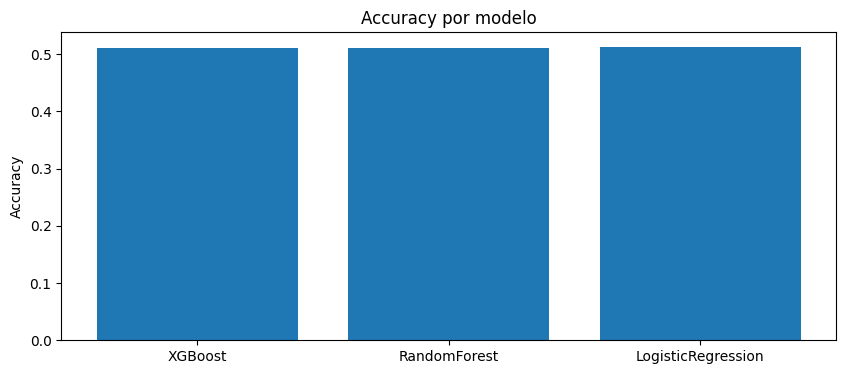

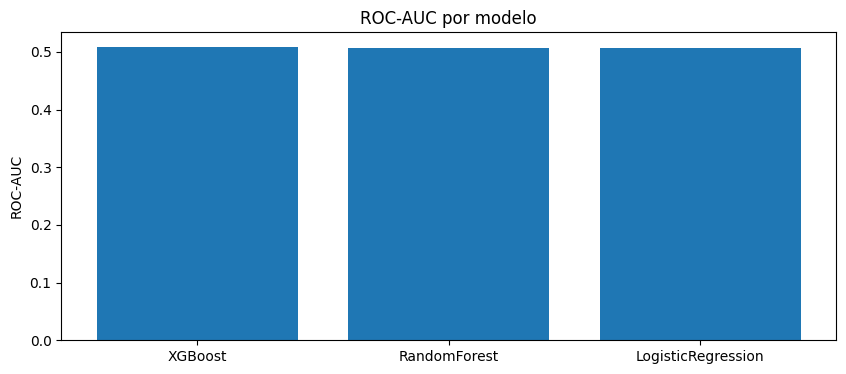

In [25]:
resultados_df = resultados_df.set_index("model")

plt.figure(figsize=(10, 4))
plt.bar(resultados_df.index, resultados_df["accuracy"])
plt.title("Accuracy por modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

if resultados_df["auc"].notna().any():
    plt.figure(figsize=(10, 4))
    plt.bar(resultados_df.index, resultados_df["auc"])
    plt.title("ROC-AUC por modelo")
    plt.ylabel("ROC-AUC")
    plt.xticks(rotation=0)
    plt.show()

## 10. Guardado del pipeline final

Una vez identificado el mejor algoritmo, el pipeline completo se guarda en formato `pickle`.

Esto permite reutilizar el modelo posteriormente sin necesidad de volver a entrenarlo, facilitando su uso en producción o en futuras predicciones.

In [14]:
import pickle

os.makedirs("src/models", exist_ok=True)

with open("src/models/finished_model.model", "wb") as archivo_salida:
    pickle.dump(best_pipeline, archivo_salida)

print("Modelo guardado en models")

Modelo guardado en models


#  Conclusiones del Proyecto:

## 1. Resultado Principal

El objetivo del proyecto ha sido evaluar si es posible predecir la **dirección diaria del precio (sube/baja)** de acciones del NASDAQ-100 utilizando exclusivamente información histórica de mercado e indicadores técnicos.

Los resultados obtenidos muestran un rendimiento ligeramente superior al azar:

- **Accuracy ≈ 51%**
- **ROC-AUC ≈ 0.50 – 0.51**

Estos valores indican que la señal predictiva detectada es **muy débil**, lo cual es coherente con la hipótesis de eficiencia de los mercados financieros, especialmente en horizontes temporales diarios.

---

## 2. Comparativa de Modelos

Entre los modelos evaluados:

- **XGBoost** y **Random Forest** presentan el mejor rendimiento en términos de ROC-AUC.
- **Regresión Logística** actúa como baseline interpretable, obteniendo resultados similares.

La mejora de los modelos más complejos frente al baseline es marginal, lo que sugiere que aumentar la complejidad del algoritmo no compensa la limitada señal informativa disponible en los datos.

---

## 3. Interpretación desde el Punto de Vista de Negocio

Desde una perspectiva financiera:

- Un accuracy cercano al 51% implica una ventaja estadística muy reducida.
- En condiciones reales, dicha ventaja podría verse erosionada por:
  - Costes de transacción  
  - Slippage  
  - Comisiones  
  - Gestión del riesgo  

Por tanto, aunque el modelo muestra una ligera capacidad predictiva, **no sería suficiente por sí solo para justificar una estrategia de trading automática sin un análisis adicional de rentabilidad ajustada al riesgo**.

---

## 4️. Limitaciones del Estudio

- Se utilizan únicamente variables técnicas derivadas del precio.
- No se incorporan factores macroeconómicos ni fundamentales.
- No se ha realizado validación walk-forward con ventanas móviles.
- No se ha simulado una estrategia completa con métricas financieras (Sharpe ratio, drawdown, etc.).

---

## 5. Líneas Futuras de Mejora

Para aumentar el potencial predictivo y la robustez del sistema, se proponen las siguientes mejoras:

- Implementar validación temporal tipo **walk-forward**.
- Entrenar modelos específicos por **ticker** o por sector.
- Incorporar variables macroeconómicas (tipos de interés, inflación, decisiones de la FED).
- Optimizar el **umbral de decisión** en lugar de utilizar 0.5 fijo.
- Simular una estrategia real comparándola con **Buy & Hold**, incluyendo costes de transacción.

---

## Conclusión Final

El estudio confirma que predecir la dirección diaria del mercado con datos históricos de precios es un problema altamente complejo y con señal limitada.

El valor principal del proyecto reside en la aplicación de una **metodología rigurosa, sin fuga de información y coherente con la naturaleza de los mercados financieros**, más que en la obtención de una alta tasa de acierto.

Este proyecto demuestra la dificultad inherente de predecir movimientos diarios del mercado utilizando únicamente información histórica de precios.

In [1]:
import xgboost
xgboost.__version__

'3.1.3'